In [1]:
### building second, slightly more complex CNN (architecture, hyperparams, ...) for protein stability prediction ###

In [3]:
### 1. imports


# basic functionality
import os 
import numpy as np
import pandas as pd
import scipy
import sklearn.metrics as skmetrics

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import lightning as L

import torchmetrics
from torchmetrics.regression import PearsonCorrCoef

In [4]:
### running on gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
### 2. Dataloading ###

aa_alphabet = 'ACDEFGHIKLMNPQRSTVWY' # amino acid alphabet
aa_to_int = {aa: i for i, aa in enumerate(aa_alphabet)} # mapping from amino acid to number

# function to one hot encode sequence
def one_hot_encode(sequence):
    # initialize a zero matrix of shape (len(sequence), len(amino_acids))
    one_hot = torch.zeros(len(sequence), len(aa_alphabet))
    for i, aa in enumerate(sequence):
        # set the column corresponding to the amino acid to 1
        one_hot[i].scatter_(0, torch.tensor([aa_to_int[aa]]), 1)
    return one_hot



# sequence data, comes already batched, so treat accordingly in dataloader (batch_size=1)
class SequenceData(Dataset):
    def __init__(self, csv_file, label_col="ddG_ML"):
        """
        Initializes the dataset. 
        input:
            csv_file: path to the relevant data file, eg. "/home/data/mega_train.csv"
        """
        self.df = pd.read_csv(csv_file, sep=",")
        self.label_col = label_col
        # only have mutation rows
        self.df = self.df[self.df.mut_type!="wt"]
        # process the mutation row
        self.df["mutation_pos"] = self.df["mut_type"].apply(lambda x: int(x[1:-1])-1) # make position start at zero
        self.df["mutation_to"] = self.df["mut_type"].apply(lambda x: aa_to_int[x[-1]]) # give numerical label to mutation

        # group by wild type
        self.df = self.df.groupby("WT_name").agg(list)
        # get wild type names
        self.wt_names = self.df.index.values
        # precompute one-hot encoding for faster training
        self.encoded_seqs = {}
        for wt_name in self.wt_names:
            # get the correct row
            mut_row = self.df.loc[wt_name]
            seq = mut_row["wt_seq"][0]
            self.encoded_seqs[wt_name] = one_hot_encode(seq)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get the wild type name
        wt_name = self.wt_names[idx]
        # get the correct row
        mut_row = self.df.loc[wt_name]
        # get the wt sequence in one hot encoding
        sequence_encoding = self.encoded_seqs[wt_name]
            # dimensions (len, 20)

        # create mask and target tensors
        mask = torch.zeros((1, len(sequence_encoding),20)) # will be 1 where we have a measurement 
        target = torch.zeros((1, len(sequence_encoding),20)) # ddg values
            # remember batch size = 1
        # all mutations from df
        positions = torch.tensor(mut_row["mutation_pos"])
        amino_acids = torch.tensor(mut_row["mutation_to"])
        # get the labels
        labels = torch.tensor(mut_row[self.label_col])

        for i in range(len(sequence_encoding)):
            mask[0,i,amino_acids[positions==i]] = 1 # one where we have data (i.e. ddG measurement)
            target[0,i,amino_acids[positions==i]] = labels[positions==i] # fill with ddG values
        
        # returns encoded sequence, mask and target sequence 
        return {"sequence": sequence_encoding[None,:,:].float(), "mask": mask, "labels": target}


        # use this structure to
        # - predict ddG for all possible mutations
        # - mask serves to only compute loss at positions where experimental data exists

In [6]:
# usage
dataset_train = SequenceData('mega_train.csv')
dataset_val= SequenceData('mega_val.csv')
# dataset_test = SequenceData('project_data/mega_test.csv') # only once available

# use batch_size=1 bc we treat each sequence as one batch
dataloader_val = DataLoader(dataset_val, batch_size=1, shuffle=False)
dataloader_train = DataLoader(dataset_train, batch_size=1, shuffle=True)
# dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

In [7]:
### 3. Data exploration ###

print('training data')
print(type(dataset_train))
# custom Pytorch Dataset object

print(len(dataset_train))
# nb of proteins

exemplary_protein = dataset_train[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


print('\nvalidation data')
print(type(dataset_val))
# custom Pytorch Dataset object

print(len(dataset_val))
# nb of proteins

exemplary_protein = dataset_val[0]
print('exemplary datapoint (wt protein 0), which will be fed into CNN as one input:')
print(type(exemplary_protein))

print({k: v.shape for k,v in exemplary_protein.items()})
    # IMPORTANT: only 'sequence' will be used for model training, 'mask' and 'labels' both serve loss computation


training data
<class '__main__.SequenceData'>
239
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 63, 20]), 'mask': torch.Size([1, 63, 20]), 'labels': torch.Size([1, 63, 20])}

validation data
<class '__main__.SequenceData'>
31
exemplary datapoint (wt protein 0), which will be fed into CNN as one input:
<class 'dict'>
{'sequence': torch.Size([1, 39, 20]), 'mask': torch.Size([1, 39, 20]), 'labels': torch.Size([1, 39, 20])}


In [8]:
print(dataloader_train)

print(type(dataset_train))

<class '__main__.SequenceData'>


In [146]:
### 4. define CNN model architecture ###

# create new model class that inherits all properties from the torch.nn.Module
class simplecnn(nn.Module):
    # initialize
    def __init__(self):
        # load parent module
        super(simplecnn, self).__init__()

        # ingredients
        self.downconv = nn.Conv1d(in_channels=20, out_channels=128,kernel_size=11,padding=5)
        self.conv2 = nn.Conv1d(in_channels=128, out_channels= 128,kernel_size=7,padding=3)
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=64,kernel_size=9, padding=4)#here dilation
        self.conv4line = nn.Conv1d(in_channels=64, out_channels=64,kernel_size=1) #kind of like linear
        self.upconv = nn.Conv1d(in_channels=64, out_channels=20,kernel_size=1)

        # recipe
    def forward(self, original_input):
        
        original_input = original_input.squeeze(0) # goal: 1x1xlen(seq)x20 --> 1xlen(seq)x20
        
        permuteddim_input = original_input.permute(0,2,1) # permute dimensions from 1x20xlen(seq) to 20x1x63 (needed for proper kernel convolutoin)
        
        featuremaps1 = F.relu(self.downconv(permuteddim_input))
        featuremaps2 = F.relu(self.conv2(featuremaps1))
        featuremaps3 = F.relu(self.conv3(featuremaps2))
        featuremaps4 = F.relu(self.conv4line(featuremaps3))
        permuteddim_output = self.upconv(featuremaps4)
        

        originaldim_output = permuteddim_output.permute (0,2,1) # permute dimensions back to 1xlen(seq)x20
        

        return originaldim_output
        

In [147]:
### 5. wrap model into lightning for training ###

class Litsimplecnn(L.LightningModule):
    def __init__(self, learning_rate):
        super().__init__()
        #self.save_hyperparameters()
        
        #self.model = simplecnn(hidden=hidden)
        self.model = simplecnn()
        self.lr = learning_rate

        self.loss_function = nn.MSELoss()
        self.mae = torchmetrics.MeanAbsoluteError() # accuracy only suited for classification (discrete outcome variable)
        #track different accuracy and mae,... metrics here

    def onlyrelevantddG(self, batch):
        '''
        returns: pred_ddg: predicted ddG for the mutation in each sample; y: true experimental ddG
        '''
        x = batch["sequence"] # --> torch.Size([1, 1, 39, 20])
        
        
        mask = batch["mask"]# --> torch.Size([1, 1, 39, 20])
    
        
        true_ddG = batch["labels"] # --> torch.Size([1, 1, 39, 20])
        true_ddG = true_ddG[mask==1] ### --> ERROR HAPPENS HERE: true_ddG is flattened to vector of size 686 !!! (instead of same dimensions as input)
        
        pred_all = self.model(x)

        pred_ddG = pred_all[mask.squeeze(0)==1]
        #true_ddG = true_ddG[mask==1]
        '''
        preds =[]
        all_y = []

        preds.append(prediction[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
        '''

        return pred_ddG, true_ddG

        
        
    def training_step(self, batch, batch_idx):
        
        pred_ddG, true_ddG = self.onlyrelevantddG(batch)

        loss = self.loss_function(pred_ddG, true_ddG)
        mae = self.mae(pred_ddG, true_ddG)

        self.log("train loss:", loss, on_epoch=True, prog_bar=True)
        self.log("train mae:", mae, on_epoch=True, prog_bar=True)
        
        return loss



    def validation_step (self, batch, batch_idx):

        pred_ddG, true_ddG = self.onlyrelevantddG(batch)
        
        loss = self.loss_function(pred_ddG, true_ddG)
        
        mae = self.mae(pred_ddG, true_ddG)
        

        self.log("val loss:", loss, on_epoch=True, prog_bar=True)
        self.log("val mae:", mae, on_epoch=True, prog_bar=True)

        return loss

        

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)
        


In [148]:
### create a tensorboard session ###
# new tab should open in your browser
%reload_ext tensorboard
%tensorboard --logdir=lightning_logs/

Reusing TensorBoard on port 6006 (pid 28421), started 1:20:43 ago. (Use '!kill 28421' to kill it.)

In [155]:
### 6. train model ###


# initialize model (always needed to have a new model for training)
lightning_model = Litsimplecnn(learning_rate=1e-4)


# instantiate lightning trainer
trainer = L.Trainer(max_epochs=25, log_every_n_steps=1)


# train
trainer.fit(lightning_model, dataloader_train, dataloader_val)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | model         | simplecnn         | 222 K  | train | 0    
1 | loss_function | MSELoss           | 0      | train | 0    
2 | mae           | MeanAbsoluteError | 0      | train | 0    
--------------------------------------------------------------------
222 K     Trainable params
0         Non-trainable p

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/course/bc_deep_learning_in_biology/tn/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


RMSE: 0.6054579615592957
Pearson r: PearsonRResult(statistic=0.5743792, pvalue=0.0)
Spearman r: SignificanceResult(statistic=0.5473067972321336, pvalue=0.0)


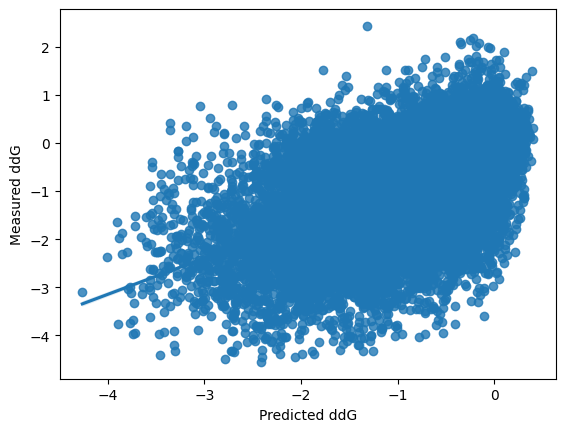

In [156]:
preds =[]
all_y = []

for batch in dataloader_val:
    # read from batch
    x = batch["sequence"]#[0]
    mask = batch["mask"]#[0] #instead of squeezing later
    target = batch["labels"]#[0]
    ## adjust to work with your model
    # predict
    prediction = lightning_model.model(x)
    preds.append(prediction[mask.squeeze(0)==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence
    all_y.append(target[mask==1].flatten().detach().numpy()) # flatten to create one dimensional vector from 2D sequence

# concatenate and plot
preds= np.concatenate(preds)
all_y = np.concatenate(all_y)

sns.regplot(x=preds,y=all_y)
plt.xlabel("Predicted ddG")
plt.ylabel("Measured ddG")

# get RMSE, Pearson and Spearman correlation 
print("RMSE:", skmetrics.mean_squared_error(all_y, preds))
print("Pearson r:", scipy.stats.pearsonr(preds, all_y))
print("Spearman r:", scipy.stats.spearmanr(preds, all_y))